In [1]:
!python --version

Python 3.7.12


In [ ]:
# install Tensorflow version 2.11.0 (latest)
# !pip install --upgrade -q pip
# !pip install --upgrade -q tensorflow==2.11.0

In [2]:
import tensorflow as tf
print(tf.__version__)

2.11.0


In [3]:
# Clone the tensorflow models repository if it doesn't already exist
import os
import pathlib

if "models" in pathlib.Path.cwd().parts:
  while "models" in pathlib.Path.cwd().parts:
    os.chdir('..')
elif not pathlib.Path('models').exists():
  !git clone --depth 1 https://github.com/tensorflow/models

Cloning into 'models'...
remote: Enumerating objects: 4401, done.
remote: Counting objects: 100% (4401/4401), done.
remote: Compressing objects: 100% (3215/3215), done.
remote: Total 4401 (delta 1188), reused 3097 (delta 1110), pack-reused 0 (from 0)
Receiving objects: 100% (4401/4401), 70.05 MiB | 38.54 MiB/s, done.
Resolving deltas: 100% (1188/1188), done.


In [4]:
cd /kaggle/working/

/kaggle/working


In [5]:
%%bash
cd /kaggle/working/models/research/
protoc object_detection/protos/*.proto --python_out=.
cp object_detection/packages/tf2/setup.py .
python -m pip install -q .

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cudf 21.12.2 requires cupy-cuda115, which is not installed.
cudf 21.12.2 requires cupy-cuda115, which is not installed.
tfx-bsl 1.12.0 requires google-api-python-client<2,>=1.7.11, but you have google-api-python-client 2.79.0 which is incompatible.
tfx-bsl 1.12.0 requires pyarrow<7,>=6, but you have pyarrow 5.0.0 which is incompatible.
tensorflow-transform 1.12.0 requires pyarrow<7,>=6, but you have pyarrow 5.0.0 which is incompatible.
pathos 0.3.0 requires dill>=0.3.6, but you have dill 0.3.1.1 which is incompatible.
onnx 1.13.1 requires protobuf<4,>=3.20.2, but you have protobuf 3.19.6 which is incompatible.
multiprocess 0.70.14 requires dill>=0.3.6, but you have dill 0.3.1.1 which is incompatible.
distributed 2021.11.2 requires dask==2021.11.2, but you have dask 2022.2.0 which is incompatible.
dask-cudf 21

In [6]:
!pip uninstall -y protobuf
!pip install protobuf==3.20.*
# and done or restart or try 2 times

Found existing installation: protobuf 3.19.6
Uninstalling protobuf-3.19.6:
  Successfully uninstalled protobuf-3.19.6
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.0 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf 21.12.2 requires cupy-cuda115, which is not installed.
tfx-bsl 1.12.0 requires google-api-python-client<2,>=1.7.11, but you have google-api-python-client 2.79.0 which is incompatible.
tfx-bsl 1.12.0 requires pyarrow<7,>=6, but you have pyarrow 5.0.0 which is incompatible.
tensorflow 2.11.0 requires protobuf<3.20,>=3.9.2, but you have protobuf 3.20.3 which is incompatible.
tensorflow-transform 1.12.0 requires pyarrow<7,>=6, but you have pyarrow 5.0.0 which is incompatible.
tensorflow-serving-api 2.11.0 requires protobuf<3.20,>=3.9.2, but you have protobuf 3.20.3 which is incompatible.
tensorboardx 2.5.1 requires

In [7]:
#run model builder test
!python /kaggle/working/models/research/object_detection/builders/model_builder_tf2_test.py

Running tests under Python 3.7.12: /opt/conda/bin/python
[ RUN      ] ModelBuilderTF2Test.test_create_center_net_deepmac
/opt/conda/lib/python3.7/site-packages/object_detection/builders/model_builder.py:1112: DeprecationWarning: The 'warn' function is deprecated, use 'warning' instead
  logging.warn(('Building experimental DeepMAC meta-arch.'
W0114 17:36:18.558582 135241696163648 model_builder.py:1112] Building experimental DeepMAC meta-arch. Some features may be omitted.
I0114 17:36:18.851185 135241696163648 test_util.py:2458] time(__main__.ModelBuilderTF2Test.test_create_center_net_deepmac): 3.28s
[       OK ] ModelBuilderTF2Test.test_create_center_net_deepmac
[ RUN      ] ModelBuilderTF2Test.test_create_center_net_model0 (customize_head_params=True)
I0114 17:36:19.624649 135241696163648 test_util.py:2458] time(__main__.ModelBuilderTF2Test.test_create_center_net_model0 (customize_head_params=True)): 0.77s
[       OK ] ModelBuilderTF2Test.test_create_center_net_model0 (customize_head_

In [8]:
import json
from collections import defaultdict
from pprint import pprint

def check_coco_json(ann_file_path):
    with open(ann_file_path, 'r') as f:
        coco_data = json.load(f)

    # Check top-level keys
    assert 'images' in coco_data, "'images' key not found in JSON"
    assert 'annotations' in coco_data, "'annotations' key not found in JSON"
    assert 'categories' in coco_data, "'categories' key not found in JSON"

    print(f"Total images: {len(coco_data['images'])}")
    print(f"Total annotations: {len(coco_data['annotations'])}")
    print(f"Total categories: {len(coco_data['categories'])}")

    print("\nSample category definitions:")
    pprint(coco_data['categories'])

    # Check required annotation keys (excluding segmentation)
    required_ann_keys = {"id", "image_id", "bbox", "category_id"}
    missing_fields = []

    for i, ann in enumerate(coco_data['annotations']):
        if not required_ann_keys.issubset(ann):
            missing_fields.append(i)

    if missing_fields:
        print(f"⚠️ Missing required fields in {len(missing_fields)} annotations. Examples: {missing_fields[:5]}")
    else:
        print("✅ All annotations have required fields: 'id', 'image_id', 'bbox', 'category_id'")

    # Optional: Check iscrowd and area fields
    optional_fields = ["iscrowd", "area"]
    count_missing = defaultdict(int)

    for ann in coco_data['annotations']:
        for field in optional_fields:
            if field not in ann:
                count_missing[field] += 1

    for field in optional_fields:
        if count_missing[field]:
            print(f"⚠️ Missing '{field}' in {count_missing[field]} annotations")
        else:
            print(f"✅ All annotations have '{field}'")

# Example usage:
check_coco_json("/kaggle/input/sis-det-tfrecords/instances_train_det.json")
check_coco_json("/kaggle/input/sis-det-tfrecords/instances_valid_det.json")

Total images: 2855
Total annotations: 4895
Total categories: 6

Sample category definitions:
[{'id': 1, 'name': 'Grasper'},
 {'id': 2, 'name': 'Harmonic_Ace'},
 {'id': 3, 'name': 'Myoma_Screw'},
 {'id': 4, 'name': 'Needle_Holder'},
 {'id': 5, 'name': 'Suction'},
 {'id': 6, 'name': 'Trocar'}]
✅ All annotations have required fields: 'id', 'image_id', 'bbox', 'category_id'
✅ All annotations have 'iscrowd'
✅ All annotations have 'area'
Total images: 841
Total annotations: 1215
Total categories: 6

Sample category definitions:
[{'id': 1, 'name': 'Grasper'},
 {'id': 2, 'name': 'Harmonic_Ace'},
 {'id': 3, 'name': 'Myoma_Screw'},
 {'id': 4, 'name': 'Needle_Holder'},
 {'id': 5, 'name': 'Suction'},
 {'id': 6, 'name': 'Trocar'}]
✅ All annotations have required fields: 'id', 'image_id', 'bbox', 'category_id'
✅ All annotations have 'iscrowd'
✅ All annotations have 'area'


In [9]:
import json
import csv
import os

def coco_to_csv(coco_json, image_dir, output_csv):
    with open(coco_json, "r") as f:
        coco = json.load(f)

    # maps
    images = {img["id"]: img for img in coco["images"]}
    categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

    rows = []

    for ann in coco["annotations"]:
        if ann.get("iscrowd", 0) == 1:
            continue

        img = images[ann["image_id"]]
        filename = img["file_name"]
        width = img["width"]
        height = img["height"]

        x, y, w, h = ann["bbox"]
        if w <= 0 or h <= 0:
            continue

        xmin = x
        ymin = y
        xmax = x + w
        ymax = y + h

        if xmax <= xmin or ymax <= ymin:
            continue

        rows.append([
            filename,
            width,
            height,
            categories[ann["category_id"]],
            xmin,
            ymin,
            xmax,
            ymax
        ])

    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename","width","height","class","xmin","ymin","xmax","ymax"])
        writer.writerows(rows)

    print(f"CSV written: {output_csv} ({len(rows)} boxes)")

In [10]:
train_images_dir="/kaggle/input/sis-det-tfrecords/images-20260114T080732Z-3-001/images/train"
train_annotation_file="/kaggle/input/sis-det-tfrecords/instances_train_det.json"

valid_images_dir="/kaggle/input/sis-det-tfrecords/images-20260114T080732Z-3-001/images/valid"
valid_annotation_file="/kaggle/input/sis-det-tfrecords/instances_valid_det.json"

!mkdir /kaggle/working/sis_det_tfrecords
coco_to_csv(train_annotation_file, train_images_dir, "/kaggle/working/sis_det_tfrecords/train.csv")
coco_to_csv(valid_annotation_file, valid_images_dir, "/kaggle/working/sis_det_tfrecords/valid.csv")

CSV written: /kaggle/working/sis_det_tfrecords/train.csv (4895 boxes)
CSV written: /kaggle/working/sis_det_tfrecords/valid.csv (1215 boxes)


In [11]:
import pandas as pd

df = pd.read_csv("/kaggle/working/sis_det_tfrecords/train.csv")

print(df.head())
print(df.isna().sum())
print("Rows:", len(df))

bad = df[
    (df.xmin < 0) | (df.ymin < 0) |
    (df.xmax > df.width) | (df.ymax > df.height) |
    (df.xmax <= df.xmin) | (df.ymax <= df.ymin)
]

print("Bad boxes:", len(bad))

df["bw"] = df.xmax - df.xmin
df["bh"] = df.ymax - df.ymin
df["area"] = df.bw * df.bh

print(df[["bw","bh","area"]].describe())

print(df["class"].value_counts())

img_counts = df.groupby("filename").size()
print(img_counts.describe())

                                            filename  width  height  \
0  Laparoscopic-Surgery-for-Chronic-Ectopic-Pregn...   1920    1080   
1  Laparoscopic-Hysterectomy-with-Ureteral-200-_j...    640     360   
2  Laparoscopic-Hysterectomy-with-Ureteral-232-_j...    640     360   
3  Laparoscopic-Hysterectomy-with-Ureteral-232-_j...    640     360   
4  Laparoscopic-Hysterectomy-with-Ureteral-232-_j...    640     360   

           class        xmin    ymin        xmax        ymax  
0   Harmonic_Ace  132.500000  471.25  826.250000  735.000000  
1   Harmonic_Ace   19.000000   71.00  205.000000  152.500000  
2  Needle_Holder   47.000000   30.00  226.000000   88.500000  
3  Needle_Holder   26.000000   76.00  299.000000  195.500000  
4        Grasper  439.615385    0.00  580.769231   58.461538  
filename    0
width       0
height      0
class       0
xmin        0
ymin        0
xmax        0
ymax        0
dtype: int64
Rows: 4895
Bad boxes: 0
                bw           bh          area


(-0.5, 1905.5, 1079.5, -0.5)

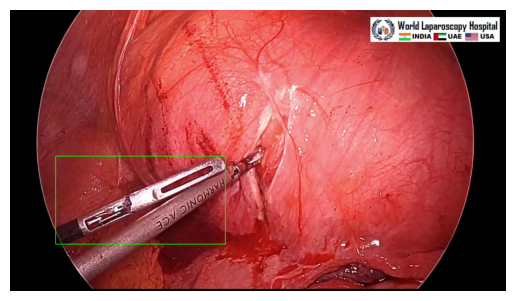

In [13]:
import cv2
import matplotlib.pyplot as plt

row = df.sample(1).iloc[0]
img = cv2.imread(os.path.join(train_images_dir, row.filename))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

cv2.rectangle(
    img,
    (int(row.xmin), int(row.ymin)),
    (int(row.xmax), int(row.ymax)),
    (0,255,0), 2
)

plt.imshow(img)
plt.axis("off")

In [14]:
%%writefile /kaggle/working/sis_det_tfrecords/label_map.pbtxt
item {
    id: 1
    name: 'Grasper'
}
item {
    id: 2
    name: 'Harmonic_Ace'
}
item {
    id: 3
    name: 'Myoma_Screw'
}
item {
    id: 4
    name: 'Needle_Holder'
}
item {
    id: 5
    name: 'Suction'
}
item {
    id: 6
    name: 'Trocar'
}

Writing /kaggle/working/sis_det_tfrecords/label_map.pbtxt


In [15]:
# !wget https://raw.githubusercontent.com/hugozanini/object-detection/master/generate_tf_record.py

In [16]:
'''
Reference repo: https://github.com/EdjeElectronics/TensorFlow-Object-Detection-API-Tutorial-Train-Multiple-Objects-Windows-10/blob/master/generate_tfrecord.py
'''

import tensorflow as tf
import pandas as pd
import argparse
import logging
import io
import os

from PIL import Image
from object_detection.utils import dataset_util
from collections import namedtuple, OrderedDict

logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.INFO)

class TFRecord:
    def __init__(self, labelmap_file) -> None:
        f = open("/kaggle/working/sis_det_tfrecords/label_map.pbtxt", "r")
        labelmap = f.read()
        self.class_names = self.init_names(labelmap)
        print(self.class_names)

    def init_names(self, labelmap):
        items = labelmap.split('item')[1:]
        items_dict = {}
    
        for item in items:
            if 'name' not in item or 'id' not in item:
                continue
    
            name = item.split('name')[1].split("'")[1]
            name_id = int(item.split('id')[1].split(':')[1].split('\n')[0])
    
            items_dict[name] = name_id
    
        return items_dict

    def class_text_to_int(self, row_label) -> int:
        if self.class_names[row_label] is not None:
            return self.class_names[row_label]
        else:
            None

    def split(self, df, group):
        data = namedtuple('data', ['filename', 'object'])
        gb = df.groupby(group)
        return [data(filename, gb.get_group(x)) for filename, x in \
                                            zip(gb.groups.keys(), gb.groups)]


    def create_tf(self, group, path):
        with tf.io.gfile.GFile(os.path.join(path, '{}'\
                                        .format(group.filename)), 'rb') as fid:
            encoded_jpg = fid.read()
        encoded_jpg_io = io.BytesIO(encoded_jpg)
        image = Image.open(encoded_jpg_io)
        width, height = image.size

        filename = group.filename.encode('utf8')
        image_format = b'jpg'
        xmins = []
        xmaxs = []
        ymins = []
        ymaxs = []
        classes_text = []
        classes = []

        for index, row in group.object.iterrows():
            xmins.append(row['xmin'] / width)
            xmaxs.append(row['xmax'] / width)
            ymins.append(row['ymin'] / height)
            ymaxs.append(row['ymax'] / height)
            classes_text.append(row['class'].encode('utf8'))
            classes.append(self.class_text_to_int(row['class']))

        tf_sample = tf.train.Example(features=tf.train.Features(feature={
            'image/height': dataset_util.int64_feature(height),
            'image/width': dataset_util.int64_feature(width),
            'image/filename': dataset_util.bytes_feature(filename),
            'image/source_id': dataset_util.bytes_feature(filename),
            'image/encoded': dataset_util.bytes_feature(encoded_jpg),
            'image/format': dataset_util.bytes_feature(image_format),
            'image/object/bbox/xmin': dataset_util.float_list_feature(xmins),
            'image/object/bbox/xmax': dataset_util.float_list_feature(xmaxs),
            'image/object/bbox/ymin': dataset_util.float_list_feature(ymins),
            'image/object/bbox/ymax': dataset_util.float_list_feature(ymaxs),
            'image/object/class/text':\
                                dataset_util.bytes_list_feature(classes_text),
            'image/object/class/label':\
                                    dataset_util.int64_list_feature(classes),
        }))
        return tf_sample

    def generate(self, output_path, image_dir, csv_input) -> None:
        writer = tf.io.TFRecordWriter(output_path)
        path = os.path.join(image_dir)
        data = pd.read_csv(csv_input)
        grouped = self.split(data, 'filename')

        for group in grouped:
            try:
              tf_sample = self.create_tf(group, path)
              writer.write(tf_sample.SerializeToString())
            except:
              continue
        logging.info('Successfully created the TFRecords: {}'.format(output_path))

In [17]:
tf_record = TFRecord("/kaggle/working/sis_det_tfrecords/label_map.pbtxt")
tf_record.generate("/kaggle/working/sis_det_tfrecords/train.record", train_images_dir, "/kaggle/working/sis_det_tfrecords/train.csv")
tf_record.generate("/kaggle/working/sis_det_tfrecords/valid.record", valid_images_dir, "/kaggle/working/sis_det_tfrecords/valid.csv")

{'Grasper': 1, 'Harmonic_Ace': 2, 'Myoma_Screw': 3, 'Needle_Holder': 4, 'Suction': 5, 'Trocar': 6}


In [18]:
train_record_path = '/kaggle/working/sis_det_tfrecords/train.record'
valid_record_path = '/kaggle/working/sis_det_tfrecords/valid.record'
labelmap_path = '/kaggle/working/sis_det_tfrecords/label_map.pbtxt'

In [19]:
batch_size = 8
num_steps = 3568
num_eval_steps = 104
num_classes = 6

In [20]:
!wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.tar.gz
!tar -xf faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.tar.gz

--2026-01-14 17:43:31--  http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 108.177.98.207, 74.125.20.207, 142.251.188.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|108.177.98.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353643040 (337M) [application/x-tar]
Saving to: ‘faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.tar.gz’

faster_rcnn_resnet1 100%[===================>] 337.26M   117MB/s    in 2.9s    

2026-01-14 17:43:34 (117 MB/s) - ‘faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.tar.gz’ saved [353643040/353643040]



In [22]:
fine_tune_checkpoint = '/kaggle/working/faster_rcnn_resnet101_v1_640x640_coco17_tpu-8/checkpoint/ckpt-0'

In [63]:
!wget https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/configs/tf2/faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.config

--2026-01-14 17:54:18--  https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/configs/tf2/faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.config
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3531 (3.4K) [text/plain]
Saving to: ‘faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.config’

faster_rcnn_resnet1 100%[===================>]   3.45K  --.-KB/s    in 0s      

2026-01-14 17:54:18 (41.1 MB/s) - ‘faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.config’ saved [3531/3531]



In [64]:
base_config_path = '/kaggle/working/faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.config'

In [65]:
# edit configuration file
import re

with open(base_config_path) as f:
    config = f.read()

with open('fasterrcnn_r101.config', 'w') as f:
  
  # Set labelmap path
  config = re.sub('label_map_path: ".*?"', 
             'label_map_path: "{}"'.format(labelmap_path), config)
  
  # Set fine_tune_checkpoint path
  config = re.sub('fine_tune_checkpoint: ".*?"',
                  'fine_tune_checkpoint: "{}"'.format(fine_tune_checkpoint), config)
  
  # Set train tf-record file path
  config = re.sub('(input_path: ".*?)(PATH_TO_BE_CONFIGURED/train)(.*?")', 
                  'input_path: "{}"'.format(train_record_path), config)
  
  # Set test tf-record file path
  config = re.sub('(input_path: ".*?)(PATH_TO_BE_CONFIGURED/val)(.*?")', 
                  'input_path: "{}"'.format(valid_record_path), config)
  
  # Set number of classes.
  config = re.sub('num_classes: [0-9]+',
                  'num_classes: {}'.format(num_classes), config)
  
  # Set batch size
  config = re.sub('batch_size: [0-9]+',
                  'batch_size: {}'.format(batch_size), config)
  
  # Set training steps
  config = re.sub('num_steps: [0-9]+',
                  'num_steps: {}'.format(num_steps), config)
  
  # Set fine-tune checkpoint type to detection
  config = re.sub('fine_tune_checkpoint_type: "classification"', 
             'fine_tune_checkpoint_type: "{}"'.format('detection'), config)
  
  f.write(config)

In [66]:
%cat /kaggle/working/fasterrcnn_r101.config

# Faster R-CNN with Resnet-50 (v1)
# Trained on COCO, initialized from Imagenet classification checkpoint
#
# Train on TPU-8
#
# Achieves 31.8 mAP on COCO17 val

model {
  faster_rcnn {
    num_classes: 6
    image_resizer {
      keep_aspect_ratio_resizer {
        min_dimension: 640
        max_dimension: 640
        pad_to_max_dimension: true
      }
    }
    feature_extractor {
      type: 'faster_rcnn_resnet101_keras'
      batch_norm_trainable: true
    }
    first_stage_anchor_generator {
      grid_anchor_generator {
        scales: [0.25, 0.5, 1.0, 2.0]
        aspect_ratios: [0.5, 1.0, 2.0]
        height_stride: 16
        width_stride: 16
      }
    }
    first_stage_box_predictor_conv_hyperparams {
      op: CONV
      regularizer {
        l2_regularizer {
          weight: 0.0
        }
      }
      initializer {
        truncated_normal_initializer {
          stddev: 0.01
        }
      }
    }
    first_stage_nms_score_threshold: 0.0
    first_stage_nms_iou_thresh

In [67]:
def get_pipeline_config(path):
    pipeline_config = pipeline_pb2.TrainEvalPipelineConfig()
    with tf.io.gfile.GFile(path, 'r') as f:
        text_format.Merge(f.read(), pipeline_config)

    return pipeline_config

def save_pipeline_config(pipeline_config, path):
    config_text = text_format.MessageToString(pipeline_config)
    with tf.io.gfile.GFile(path, "wb") as f:
        f.write(config_text)

In [68]:
from object_detection.protos import pipeline_pb2
from google.protobuf import text_format

In [16]:
pipeline_config_path = '/kaggle/working/fasterrcnn_r101.config'
pipeline_config = get_pipeline_config(pipeline_config_path)

In [17]:
pipeline_config.eval_config.batch_size = 1

In [ ]:
# pipeline_config.model.ssd.post_processing.batch_non_max_suppression.max_detections_per_class = 10
# pipeline_config.model.ssd.post_processing.batch_non_max_suppression.max_total_detections = 10

In [20]:
save_pipeline_config(pipeline_config, '/kaggle/working/fasterrcnn_r101.config')

In [ ]:
%cat /kaggle/working/fasterrcnn_r101.config

In [69]:
!mkdir fasterrcnn_training

In [71]:
model_dir = '/kaggle/working/fasterrcnn_training'
pipeline_config_path = '/kaggle/working/fasterrcnn_r101.config'

In [72]:
!python /kaggle/working/models/research/object_detection/model_main_tf2.py \
    --pipeline_config_path={pipeline_config_path} \
    --model_dir={model_dir} \
    --alsologtostderr \
    --num_train_steps={num_steps} \
    --sample_1_of_n_eval_examples=1 \
    --num_eval_steps={num_eval_steps}

I0114 17:57:26.973856 139681108051776 mirrored_strategy.py:374] Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
I0114 17:57:26.977278 139681108051776 config_util.py:552] Maybe overwriting train_steps: 3568
I0114 17:57:26.977494 139681108051776 config_util.py:552] Maybe overwriting use_bfloat16: False
W0114 17:57:27.028231 139681108051776 deprecation.py:356] From /opt/conda/lib/python3.7/site-packages/object_detection/model_lib_v2.py:564: StrategyBase.experimental_distribute_datasets_from_function (from tensorflow.python.distribute.distribute_lib) is deprecated and will be removed in a future version.
Instructions for updating:
rename to distribute_datasets_from_function
I0114 17:57:27.051168 139681108051776 dataset_builder.py:162] Reading unweighted datasets: ['/kaggle/working/sis_det_tfrecords/train.record']
I0114 17:57:27.051377 139681108051776 dataset_builder.py:79] Reading record datasets for input

In [74]:
# %load_ext tensorboard
# %tensorboard --logdir '/kaggle/working/fasterrcnn_training'

In [75]:
!mkdir fasterrcnn_inference_graph

In [76]:
output_directory = '/kaggle/working/fasterrcnn_inference_graph'

!python /kaggle/working/models/research/object_detection/exporter_main_v2.py \
    --trained_checkpoint_dir {model_dir} \
    --output_directory {output_directory} \
    --pipeline_config_path {pipeline_config_path}

W0114 18:57:52.828555 137490916407104 deprecation.py:356] From /opt/conda/lib/python3.7/site-packages/tensorflow/python/autograph/pyct/static_analysis/liveness.py:83: Analyzer.lamba_check (from tensorflow.python.autograph.pyct.static_analysis.liveness) is deprecated and will be removed after 2023-09-23.
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
W0114 18:57:52.903746 137490916407104 deprecation.py:628] From /opt/conda/lib/python3.7/site-packages/tensorflow/python/autograph/impl/api.py:458: calling map_fn_v2 (from tensorflow.python.ops.map_fn) with back_prop=False is deprecated and will be removed in a future version.
Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.map_fn(fn, elems, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.

In [78]:
# can download(f'/kaggle/working/fasterrcnn_inference_graph/saved_model/saved_model.pb') 

In [79]:
import io
import os
import scipy.misc
import numpy as np
import six
import time
import glob
from IPython.display import display

from six import BytesIO

import matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

import tensorflow as tf
from object_detection.utils import ops as utils_ops
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as vis_util

%matplotlib inline

In [80]:
def load_image_into_numpy_array(path):
  """Load an image from file into a numpy array.

  Puts image into numpy array to feed into tensorflow graph.
  Note that by convention we put it into a numpy array with shape
  (height, width, channels), where channels=3 for RGB.

  Args:
    path: a file path (this can be local or on colossus)

  Returns:
    uint8 numpy array with shape (img_height, img_width, 3)
  """
  img_data = tf.io.gfile.GFile(path, 'rb').read()
  image = Image.open(BytesIO(img_data))
  (im_width, im_height) = image.size
  return np.array(image.getdata()).reshape(
      (im_height, im_width, 3)).astype(np.uint8)

In [81]:
category_index = label_map_util.create_category_index_from_labelmap(labelmap_path, use_display_name=True)

In [82]:
tf.keras.backend.clear_session()
model = tf.saved_model.load(f'/kaggle/working/fasterrcnn_inference_graph/saved_model')

In [86]:
def run_inference_for_single_image(model, image):
  image = np.asarray(image)
  # The input needs to be a tensor, convert it using `tf.convert_to_tensor`.
  input_tensor = tf.convert_to_tensor(image)
  # The model expects a batch of images, so add an axis with `tf.newaxis`.
  input_tensor = input_tensor[tf.newaxis,...]

  # Run inference
  model_fn = model.signatures['serving_default']
  output_dict = model_fn(input_tensor)

  # All outputs are batches tensors.
  # Convert to numpy arrays, and take index [0] to remove the batch dimension.
  # We're only interested in the first num_detections.
  num_detections = int(output_dict.pop('num_detections'))
  output_dict = {key:value[0, :num_detections].numpy() 
                 for key,value in output_dict.items()}
  output_dict['num_detections'] = num_detections

  # detection_classes should be ints.
  output_dict['detection_classes'] = output_dict['detection_classes'].astype(np.int64)
   
  # Handle models with masks:
  if 'detection_masks' in output_dict:
    # Reframe the the bbox mask to the image size.
    detection_masks_reframed = utils_ops.reframe_box_masks_to_image_masks(
              output_dict['detection_masks'], output_dict['detection_boxes'],
               image.shape[0], image.shape[1])      
    detection_masks_reframed = tf.cast(detection_masks_reframed > 0.5,
                                       tf.uint8)
    output_dict['detection_masks_reframed'] = detection_masks_reframed.numpy()
    
  return output_dict

In [ ]:
a = 0
for image_path in glob.glob('/kaggle/input/sis-det-tfrecords/images-20260114T080732Z-3-001/images/valid/*.jpg'):
  image_np = load_image_into_numpy_array(image_path)
  output_dict = run_inference_for_single_image(model, image_np)
  vis_util.visualize_boxes_and_labels_on_image_array(
      image_np,
      output_dict['detection_boxes'],
      output_dict['detection_classes'],
      output_dict['detection_scores'],
      category_index,
      instance_masks=output_dict.get('detection_masks_reframed', None),
      use_normalized_coordinates=True,
      max_boxes_to_draw=20,
      min_score_thresh=0.3,
      line_thickness=8)
  display(Image.fromarray(image_np))
  a += 1
  if a == 5:
      break

In [88]:
# !zip -r /kaggle/working/fasterrcnnTFODfiles.zip /kaggle/working/

In [89]:
# !rm /kaggle/working/fasterrcnnTFODfiles.zip

In [90]:
# Convert to TFLite. This form of quantization is called
# post-training dynamic-range quantization in TFLite.
converter = tf.lite.TFLiteConverter.from_saved_model("/kaggle/working/fasterrcnn_inference_graph/saved_model")

# Enable TF Select ops for unsupported operations
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # Enable TF Select ops
]

# No optimizations
tflite_model = converter.convert()
open("SIS_TFOD_Fasterrcnn.tflite", "wb").write(tflite_model)

190376860

TFLite outputs types and shapes:
  Output type=<class 'numpy.ndarray'>, shape=(1, 300, 4)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300)
  Output type=<class 'numpy.ndarray'>, shape=(1,)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300, 7)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300, 4)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300, 7)
TFLite outputs types and shapes:
  Output type=<class 'numpy.ndarray'>, shape=(1, 300, 4)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300)
  Output type=<class 'numpy.ndarray'>, shape=(1,)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300, 7)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300, 4)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300)
  Output type=<class 'numpy.ndarray'>, shape=(1, 300, 7)
TFLite outputs types and shapes:
  Output type=<class 

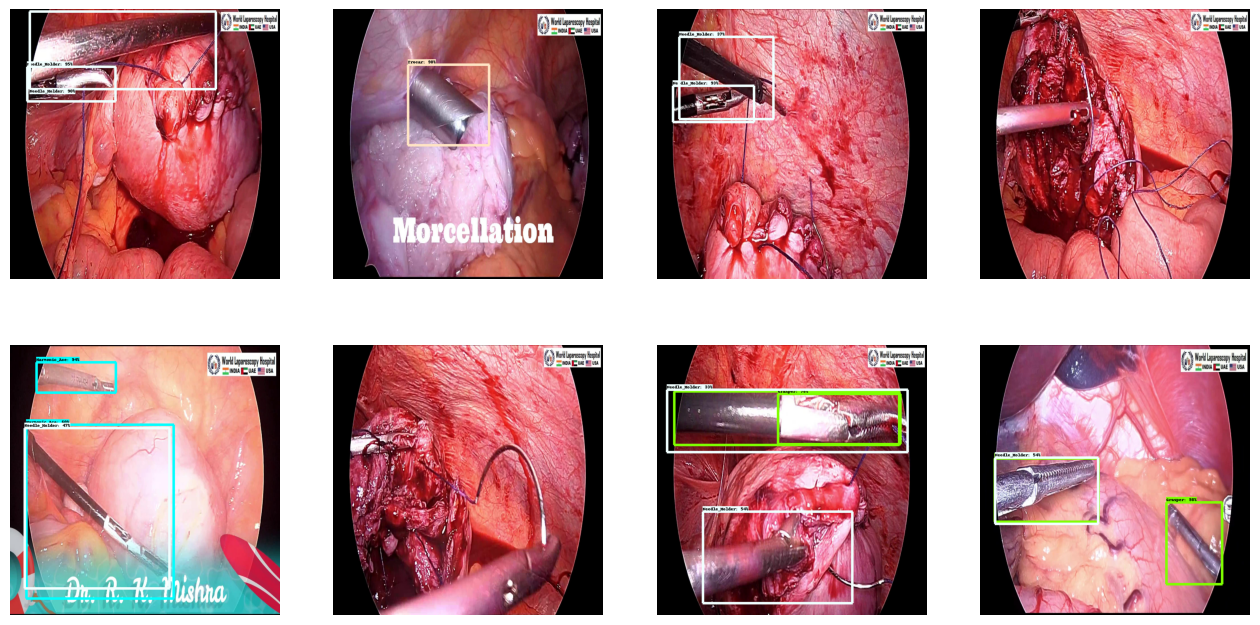

In [108]:
import os, random, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
val_dir = "/kaggle/input/sis-det-tfrecords/images-20260114T080732Z-3-001/images/valid"

min_score_thresh = 0.3
# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# ---- MODEL DIMENSIONS FOR TFLITE INFERENCE ----
MODEL_H = 640   # TFLite model input height
MODEL_W = 640   # TFLite model input width

# ---------- LOAD TFLITE ----------
interpreter = tf.lite.Interpreter(
    model_path="/kaggle/working/SIS_TFOD_Fasterrcnn.tflite"
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ---- FIX MODEL INPUT SHAPE (ONCE) ----
interpreter.resize_tensor_input(
    input_details[0]["index"],
    [1, MODEL_H, MODEL_W, 3],
    strict=True
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

# load images
raw_images = []
orig_images = []

for p in sample_imgs:
    img = cv2.imread(p)
    orig_images.append(img.copy())
    raw_images.append(np.array(img))

plt.figure(figsize=(4 * cols, 4 * rows))

for i, image in enumerate(raw_images):
    plt.subplot(2, 4, i+1)
    input_image = cv2.resize(image, (640, 640))
    input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
    image_np = input_image.copy()
    input_image = input_image[:,:,::-1]
    input_image = np.expand_dims(input_image, 0)

    input_data = (input_image).astype(np.uint8)
    interpreter.set_tensor(input_details[0]["index"], input_data)

    # run inference
    interpreter.invoke()

    # get outputs
    tflite_outputs = []
    print("TFLite outputs types and shapes:")
    for out_detail in output_details:
        output_tensor = interpreter.get_tensor(out_detail["index"])
        tflite_outputs.append(output_tensor)
        print(f"  Output type={type(output_tensor)}, shape={output_tensor.shape}")
    vis_util.visualize_boxes_and_labels_on_image_array(
        image_np,
        tflite_outputs[4][0],
        tflite_outputs[5][0].astype(int),
        tflite_outputs[6][0],
        category_index=category_index,
        use_normalized_coordinates=True,
        max_boxes_to_draw=20,
        min_score_thresh=min_score_thresh,
        agnostic_mode=False,
        instance_masks=None,
        line_thickness=6)
    plt.imshow(image_np)
    plt.axis('off')

plt.show()

In [109]:
def class_wise_nms(
    boxes, scores,
    score_thresh=0.5,
    iou_thresh=0.45,
    max_detections_per_class=20
):
    final_boxes, final_classes, final_scores = [], [], []
    num_classes = scores.shape[1]

    for cls in range(1, num_classes):
        cls_scores = scores[:, cls]
        keep = cls_scores >= score_thresh
        if not np.any(keep):
            continue

        cls_boxes = boxes[keep]
        cls_scores = cls_scores[keep]

        selected = tf.image.non_max_suppression(
            cls_boxes,
            cls_scores,
            max_output_size=max_detections_per_class,
            iou_threshold=iou_thresh
        ).numpy()

        final_boxes.append(cls_boxes[selected])
        final_scores.append(cls_scores[selected])
        final_classes.append(
            np.full(len(selected), cls, dtype=np.int32)
        )

    if not final_boxes:
        return np.empty((0,4)), np.empty((0,)), np.empty((0,))

    return (
        np.concatenate(final_boxes),
        np.concatenate(final_classes),
        np.concatenate(final_scores)
    )

In [110]:
def global_nms(
    boxes, classes, scores,
    iou_thresh=0.5,
    max_detections=50
):
    selected = tf.image.non_max_suppression(
        boxes,
        scores,
        max_output_size=max_detections,
        iou_threshold=iou_thresh
    ).numpy()

    return (
        boxes[selected],
        classes[selected],
        scores[selected]
    )

In [114]:
def draw_labels_cv2(image, boxes, classes, scores, category_index,
                    font_scale=0.9, thickness=2):
    h, w, _ = image.shape

    for box, cls, score in zip(boxes, classes, scores):
        ymin, xmin, ymax, xmax = box
        x1, y1 = int(xmin * w), int(ymin * h)
        x2, y2 = int(xmax * w), int(ymax * h)

        if cls == 0 or cls not in category_index:
            continue

        label = f"{category_index[cls]['name']}: {score:.2f}"

        (tw, th), _ = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX,
            font_scale, thickness
        )

        cv2.rectangle(image,
                      (x1, y1 - th - 6),
                      (x1 + tw + 4, y1),
                      (0, 0, 0), -1)

        cv2.putText(
            image, label,
            (x1 + 2, y1 - 4),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA
        )

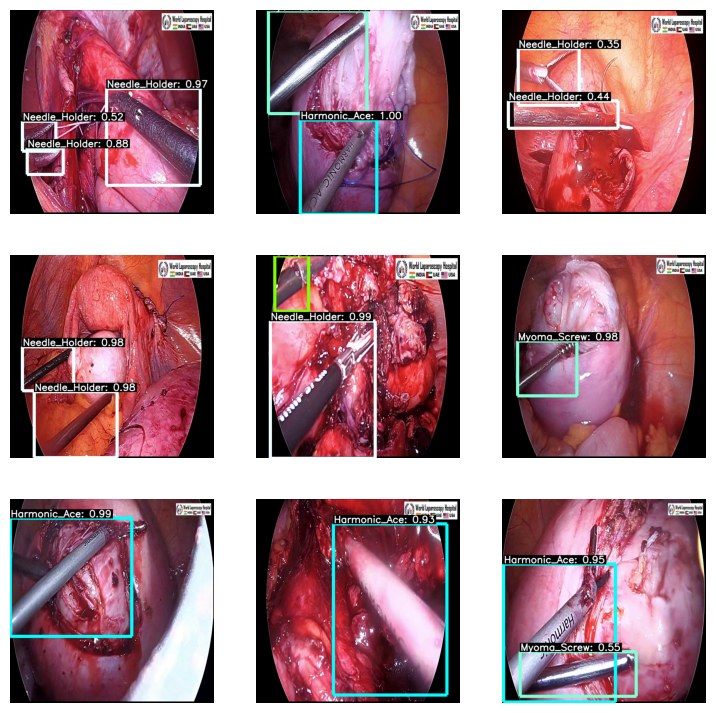

In [115]:
import os, random, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
val_dir = "/kaggle/input/sis-det-tfrecords/images-20260114T080732Z-3-001/images/train"

min_score_thresh = 0.3
# visualization layout
N = 9
cols = 3
rows = int(np.ceil(N / cols))

# ---- MODEL DIMENSIONS FOR TFLITE INFERENCE ----
MODEL_H = 640   # TFLite model input height
MODEL_W = 640   # TFLite model input width

# ---------- LOAD TFLITE ----------
interpreter = tf.lite.Interpreter(
    model_path="/kaggle/working/SIS_TFOD_Fasterrcnn.tflite"
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ---- FIX MODEL INPUT SHAPE (ONCE) ----
interpreter.resize_tensor_input(
    input_details[0]["index"],
    [1, MODEL_H, MODEL_W, 3],
    strict=True
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

# load images
raw_images = []
orig_images = []

for p in sample_imgs:
    img = cv2.imread(p)
    orig_images.append(img.copy())
    raw_images.append(np.array(img))

plt.figure(figsize=(3 * cols, 3 * rows))

for i, image in enumerate(raw_images):
    plt.subplot(3, 3, i+1)

    input_image = cv2.resize(image, (640, 640))
    input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
    image_np = input_image.copy()

    # BGR → RGB
    input_image = input_image[:, :, ::-1]
    input_image = np.expand_dims(input_image, 0).astype(np.uint8)

    interpreter.set_tensor(input_details[0]["index"], input_image)
    interpreter.invoke()

    # -------- get TFLite outputs --------
    tflite_outputs = [
        interpreter.get_tensor(o["index"]) for o in output_details
    ]

    # RAW outputs (before NMS)
    raw_boxes  = tflite_outputs[0][0]   # (49104, 4)
    raw_scores = tflite_outputs[3][0]   # (49104, num_classes)

    # -------- CUSTOM NMS --------
    boxes, classes, scores = class_wise_nms(
        raw_boxes,
        raw_scores,
        score_thresh=min_score_thresh,
        iou_thresh=0.3,
        max_detections_per_class=10
    )

    boxes, classes, scores = global_nms(
        boxes,
        classes,
        scores,
        iou_thresh=0.3,
        max_detections=10
    )
    # -------- visualize --------
    vis_util.visualize_boxes_and_labels_on_image_array(
        image_np,
        boxes,
        classes,
        scores,
        category_index=category_index,
        use_normalized_coordinates=True,
        min_score_thresh=min_score_thresh,
        skip_labels=True,
        skip_scores=True,
        line_thickness=10
    )

    # draw big labels
    draw_labels_cv2(
        image_np,
        boxes,
        classes,
        scores,
        category_index,
        font_scale=1.0,
        thickness=2
    )

    plt.imshow(image_np)
    plt.axis("off")

plt.show()

---